# Figure 3

Cross-dataset clinical associations — SEX, predisposition, race, AGE / tumor fraction / tumor ploidy per group, and numeric correlations

3.A
Overall cohort: 2192 M / 1859 F = 4051 samples, 45.9%F
  FDR q matches clinical_associations_results.csv
26 groups tested (n>=20); 6 FDR-significant (q<0.05)
  Ewing sarcoma: 26.1%F  N=46  p=0.001641  q=0.0142  *
  Adamantinomatous Craniopharyngioma: 34.8%F  N=115  p=0.001413  q=0.0142  *
  Ganglioglioma: 38.4%F  N=151  p=0.005482  q=0.0238  *
  Medulloblastoma: 40.7%F  N=440  p=0.000108  q=0.0028  **
  Ependymoma: 41.7%F  N=338  p=0.002722  q=0.0177  *
  Low-grade glioma: 45.1%F  N=861  p=0.004174  q=0.0217  *


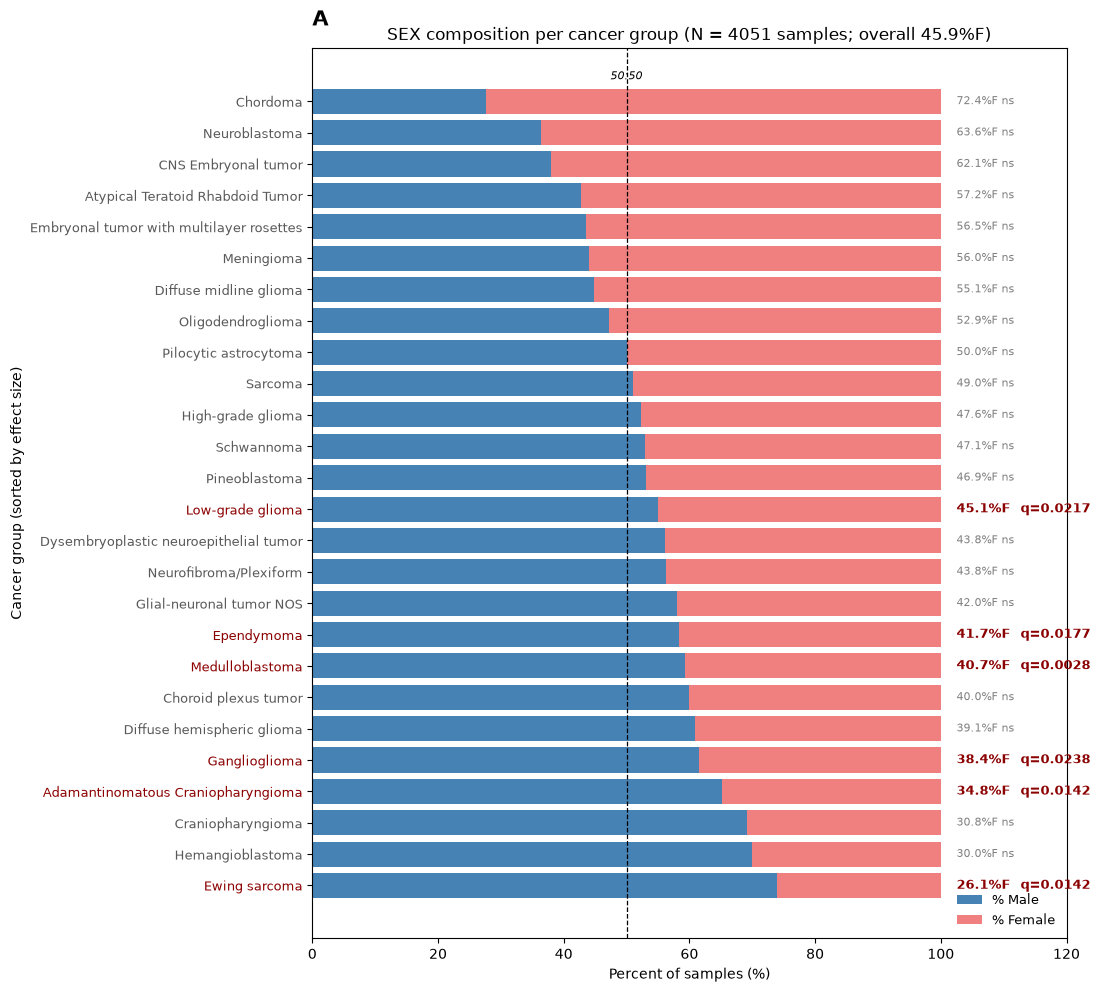

In [1]:
# Panel 3.A — SEX composition per cancer group (binomial vs 50:50)
# context/figure_instructions/fig_clinical_association.md
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest, chi2_contingency, fisher_exact, chisquare
from scipy.stats import kruskal, mannwhitneyu, spearmanr
import statsmodels.stats.multitest as smm

PATIENT_FILE = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_patient_attributes.txt"
SAMPLE_FILE  = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_sample_attributes.txt"
RESULTS_CSV  = "/home/alon/menow_home_ass/notebooks/clinical_associations/clinical_associations_results.csv"

pat = pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                  dtype={"AGE": float, "AGE_IN_DAYS": float,
                         "OS_MONTHS": float, "EFS_MONTHS": float})
smp = pd.read_csv(SAMPLE_FILE, sep="\t", header=4)
df = pat.merge(smp, on="PATIENT_ID", how="inner")   # 4312 merged rows

df["RACE"] = df["RACE"].fillna("Unknown").replace({"Not Reported": "Unknown",
                                                   "Reported Unknown": "Unknown"})
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].fillna("Unknown")
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].replace("Not Reported", "Unknown")
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].replace("None documented", "No predisposition")
for col in ["SEX", "CANCER_GROUP", "CANCER_PREDISPOSITIONS", "RACE"]:
    if col in df.columns:
        df[col] = df[col].astype(str)
df = df[df["CANCER_GROUP"].notna() & (df["CANCER_GROUP"] != "nan")].copy()  # 4074 samples

race_group_map = {
    "White": "White",
    "Black or African American": "Black",
    "Asian": "Asian",
    "More Than One Race": "Other",
    "Other": "Other",
    "American Indian or Alaska Native": "Other",
    "Native Hawaiian or Other Pacific Islander": "Other",
    "Unknown": "Unknown",
}
df["RACE_GROUP"] = df["RACE"].map(race_group_map).fillna("Other")

def sig_star(q):
    if q < 0.001:
        return "***"
    if q < 0.01:
        return "**"
    if q < 0.05:
        return "*"
    return "ns"

def check_fdr(fam, records):
    """records: list of (group, q). Assert q matches CSV FDR_WithinFamily."""
    csv_fdr = pd.read_csv(RESULTS_CSV)
    csv_map = csv_fdr[csv_fdr["Comparison"] == fam].set_index("Group")["FDR_WithinFamily"]
    bad = [(g, q, float(csv_map.loc[g])) for g, q in records
           if g in csv_map.index and abs(float(q) - float(csv_map.loc[g])) > 1e-6]
    if bad:
        print("  !! FDR q vs CSV MISMATCH:", bad)
    else:
        print("  FDR q matches clinical_associations_results.csv")


print("3.A")
sex_sub = df[df["SEX"].isin(["Female", "Male"])].copy()
oc = sex_sub["SEX"].value_counts()
n_male, n_fem, n_sex = int(oc.get("Male", 0)), int(oc.get("Female", 0)), len(sex_sub)
pct_f_overall = n_fem / n_sex * 100
print("Overall cohort: %d M / %d F = %d samples, %.1f%%F" % (n_male, n_fem, n_sex, pct_f_overall))

rows = []
for g in sorted(sex_sub["CANCER_GROUP"].unique()):
    gg = sex_sub[sex_sub["CANCER_GROUP"] == g]
    n = len(gg)
    if n < 20:
        continue
    nf = int((gg["SEX"] == "Female").sum())
    p = round(binomtest(nf, n, 0.5, alternative="two-sided").pvalue, 6)
    rows.append({"Group": g, "N": n, "nF": nf, "p": p})
qs = smm.multipletests(np.array([r["p"] for r in rows]), method="fdr_bh")[1]
for r, q in zip(rows, qs):
    r["q"] = q
# sorted by effect size (difference from 50%): (nF - nM) / N ascending
rows.sort(key=lambda r: (r["nF"] - (r["N"] - r["nF"])) / r["N"])

check_fdr("SEX enrichment", [(r["Group"], r["q"]) for r in rows])
n_sig = sum(1 for r in rows if r["q"] < 0.05)
print("%d groups tested (n>=20); %d FDR-significant (q<0.05)" % (len(rows), n_sig))
for r in rows:
    if r["q"] < 0.05:
        print("  %s: %.1f%%F  N=%d  p=%.4g  q=%.4f  %s" % (
            r["Group"], 100 * r["nF"] / r["N"], r["N"], r["p"], r["q"], sig_star(r["q"])))

fig, ax = plt.subplots(figsize=(11, 10))
y = np.arange(len(rows))
pct_m = np.array([100 * (r["N"] - r["nF"]) / r["N"] for r in rows])
pct_f = np.array([100 * r["nF"] / r["N"] for r in rows])
ax.barh(y, pct_m, color="steelblue", label="% Male")
ax.barh(y, pct_f, left=pct_m, color="lightcoral", label="% Female")
ax.axvline(50, color="black", ls="--", lw=0.9)
for yi, r in zip(y, rows):
    pF = 100 * r["nF"] / r["N"]
    if r["q"] < 0.05:
        ax.text(102.5, yi, "%.1f%%F  q=%.4f" % (pF, r["q"]), va="center", ha="left",
                fontsize=9, color="darkred", fontweight="bold")
    else:
        ax.text(102.5, yi, "%.1f%%F ns" % pF, va="center", ha="left", fontsize=8, color="gray")
ax.set_yticks(y)
ax.set_yticklabels([r["Group"] for r in rows], fontsize=9)
for tk, r in zip(ax.get_yticklabels(), rows):
    tk.set_color("darkred" if r["q"] < 0.05 else "0.35")
ax.set_xlim(0, 120)
ax.set_xlabel("Percent of samples (%)")
ax.set_ylabel("Cancer group (sorted by effect size)")
ax.set_title("SEX composition per cancer group (N = %d samples; overall %.1f%%F)" % (n_sex, pct_f_overall))
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.text(50, len(rows) - 0.3, "50:50", ha="center", fontsize=8, color="black", style="italic")
ax.text(0.0, 1.02, "A", transform=ax.transAxes, fontsize=15, fontweight="bold",
        va="bottom", ha="left")
fig.tight_layout()
plt.show()


3.B
Predisposed samples: 368 / 4074 = 9.0% of samples (368/4074); 23 categories
   130  Neurofibromatosis, Type 1 (NF-1)
    64  Other inherited conditions NOS
    58  Li-Fraumeni syndrome (TP53)
    40  Neurofibromatosis, Type 2 (NF-2)
    14  Tuberous Sclerosis (TSC1, TSC2)
    10  Lynch Syndrome (PMS2, MLH1, MSH2, MSH6)
     8  Von Hippel-Lindau (VHL)
     7  Rhabdoid tumor predisposition syndrome (SMARCB1, SMARCA4)
     6  Li-Fraumeni syndrome (TP53),Neurofibromatosis, Type 1 (NF-1)
     6  Constitutional Mismatch Repair Deficiency Syndrome (biallelic PMS2, MLH1, MSH2, MSH6),Lynch Syndrome (PMS2, MLH1, MSH2, MSH6)
  FDR q matches clinical_associations_results.csv
5 cancer groups tested (n>=20 predisposed samples)
  Atypical Teratoid Rhabdoid Tumor: N=29 p=0 q=0 V=0.5592 top3=[('Other inherited conditions NOS', 12), ('Rhabdoid tumor predisposition syndrome (SMARCB1', 7), ('Neurofibromatosis', 6)]
  High-grade glioma: N=80 p=0 q=0 V=0.4736 top3=[('Li-Fraumeni syndrome (TP53)', 21), (

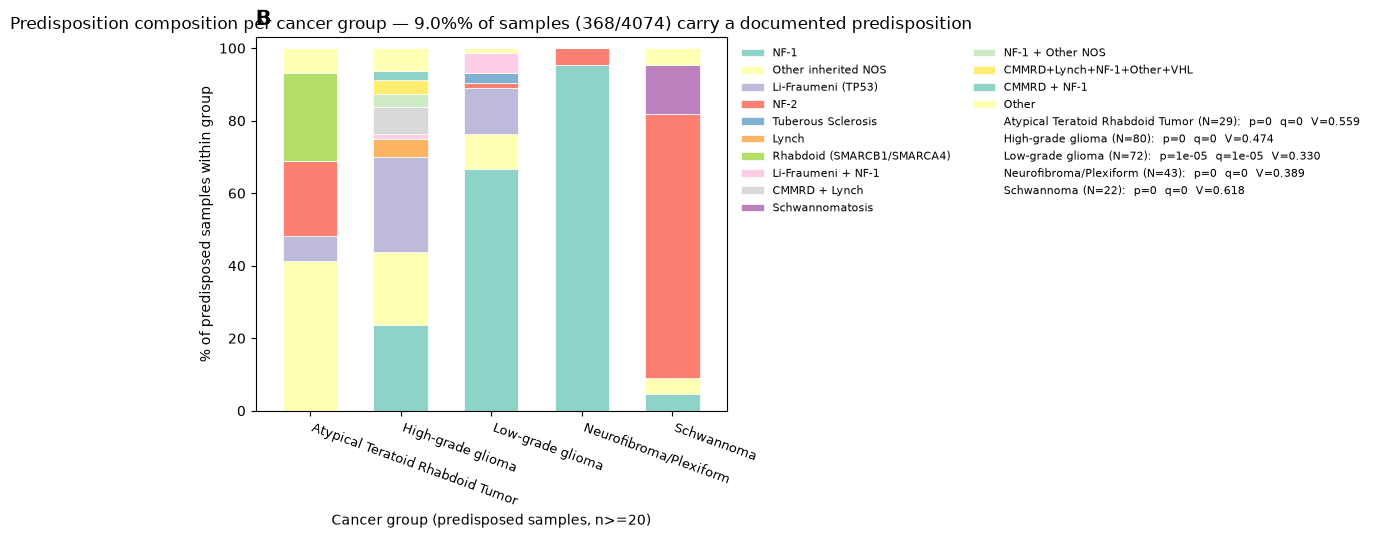

In [2]:
# Panel 3.B — Predisposition composition per cancer group
# context/figure_instructions/fig_clinical_association.md
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest, chi2_contingency, fisher_exact, chisquare
from scipy.stats import kruskal, mannwhitneyu, spearmanr
import statsmodels.stats.multitest as smm

PATIENT_FILE = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_patient_attributes.txt"
SAMPLE_FILE  = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_sample_attributes.txt"
RESULTS_CSV  = "/home/alon/menow_home_ass/notebooks/clinical_associations/clinical_associations_results.csv"

pat = pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                  dtype={"AGE": float, "AGE_IN_DAYS": float,
                         "OS_MONTHS": float, "EFS_MONTHS": float})
smp = pd.read_csv(SAMPLE_FILE, sep="\t", header=4)
df = pat.merge(smp, on="PATIENT_ID", how="inner")   # 4312 merged rows

df["RACE"] = df["RACE"].fillna("Unknown").replace({"Not Reported": "Unknown",
                                                   "Reported Unknown": "Unknown"})
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].fillna("Unknown")
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].replace("Not Reported", "Unknown")
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].replace("None documented", "No predisposition")
for col in ["SEX", "CANCER_GROUP", "CANCER_PREDISPOSITIONS", "RACE"]:
    if col in df.columns:
        df[col] = df[col].astype(str)
df = df[df["CANCER_GROUP"].notna() & (df["CANCER_GROUP"] != "nan")].copy()  # 4074 samples

race_group_map = {
    "White": "White",
    "Black or African American": "Black",
    "Asian": "Asian",
    "More Than One Race": "Other",
    "Other": "Other",
    "American Indian or Alaska Native": "Other",
    "Native Hawaiian or Other Pacific Islander": "Other",
    "Unknown": "Unknown",
}
df["RACE_GROUP"] = df["RACE"].map(race_group_map).fillna("Other")

def sig_star(q):
    if q < 0.001:
        return "***"
    if q < 0.01:
        return "**"
    if q < 0.05:
        return "*"
    return "ns"

def check_fdr(fam, records):
    """records: list of (group, q). Assert q matches CSV FDR_WithinFamily."""
    csv_fdr = pd.read_csv(RESULTS_CSV)
    csv_map = csv_fdr[csv_fdr["Comparison"] == fam].set_index("Group")["FDR_WithinFamily"]
    bad = [(g, q, float(csv_map.loc[g])) for g, q in records
           if g in csv_map.index and abs(float(q) - float(csv_map.loc[g])) > 1e-6]
    if bad:
        print("  !! FDR q vs CSV MISMATCH:", bad)
    else:
        print("  FDR q matches clinical_associations_results.csv")


print("3.B")
pred_filter = ["No predisposition", "Unknown", "nan", ""]
pred_sub = df[~df["CANCER_PREDISPOSITIONS"].isin(pred_filter)].copy()
print("Predisposed samples: %d / %d = %.1f%% of samples (368/4074); %d categories" % (
    len(pred_sub), len(df), len(pred_sub) / len(df) * 100, pred_sub["CANCER_PREDISPOSITIONS"].nunique()))
pc = pred_sub["CANCER_PREDISPOSITIONS"].value_counts()
for v, c in pc.head(10).items():
    print("  %4d  %s" % (c, v))

def cramers_v(chi2, n, k, r):
    phi2 = chi2 / n
    phi2_corrected = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    k_corrected = k - ((k - 1) ** 2) / (n - 1)
    r_corrected = r - ((r - 1) ** 2) / (n - 1)
    denom = min(k_corrected - 1, r_corrected - 1)
    if denom <= 0:
        return 0.0
    return np.sqrt(phi2_corrected / denom)

rows = []
for group in sorted(pred_sub["CANCER_GROUP"].unique()):
    g = pred_sub[pred_sub["CANCER_GROUP"] == group]
    n = len(g)
    if n < 20:
        continue
    other = pred_sub[pred_sub["CANCER_GROUP"] != group]
    g_dist = g["CANCER_PREDISPOSITIONS"].value_counts()
    other_dist = other["CANCER_PREDISPOSITIONS"].value_counts()
    all_cats = sorted(set(g_dist.index) | set(other_dist.index))
    table = np.array([[g_dist.get(c, 0) for c in all_cats],
                      [other_dist.get(c, 0) for c in all_cats]])
    expected_v = np.outer(table.sum(axis=1), table.sum(axis=0)) / table.sum()
    has_small = (expected_v < 5).any()
    if has_small and table.shape[1] == 2:
        odds_ratio, p = fisher_exact(table)
        effect = round(np.log(odds_ratio), 4) if odds_ratio > 0 else 0.0
    else:
        chi2v, p, dof, exp = chi2_contingency(table)
        effect = round(cramers_v(chi2v, table.sum(), table.shape[0], table.shape[1]), 4)
    rows.append({"Group": group, "N": n, "p": round(p, 6), "V": effect, "g_dist": g_dist})
qs = smm.multipletests(np.array([r["p"] for r in rows]), method="fdr_bh")[1]
for r, q in zip(rows, qs):
    r["q"] = q

check_fdr("Predisposition profile", [(r["Group"], r["q"]) for r in rows])
print("%d cancer groups tested (n>=20 predisposed samples)" % len(rows))
for r in rows:
    top3 = sorted(r["g_dist"].items(), key=lambda x: x[1], reverse=True)[:3]
    print("  %s: N=%d p=%.4g q=%.4g V=%.4f top3=%s" % (
        r["Group"], r["N"], r["p"], r["q"], r["V"], [(k.split(",")[0], v) for k, v in top3]))

short = {
    "Neurofibromatosis, Type 1 (NF-1)": "NF-1",
    "Other inherited conditions NOS": "Other inherited NOS",
    "Li-Fraumeni syndrome (TP53)": "Li-Fraumeni (TP53)",
    "Neurofibromatosis, Type 2 (NF-2)": "NF-2",
    "Tuberous Sclerosis (TSC1, TSC2)": "Tuberous Sclerosis",
    "Lynch Syndrome (PMS2, MLH1, MSH2, MSH6)": "Lynch",
    "Von Hippel-Lindau (VHL)": "VHL",
    "Rhabdoid tumor predisposition syndrome (SMARCB1, SMARCA4)": "Rhabdoid (SMARCB1/SMARCA4)",
    "Li-Fraumeni syndrome (TP53),Neurofibromatosis, Type 1 (NF-1)": "Li-Fraumeni + NF-1",
    "Constitutional Mismatch Repair Deficiency Syndrome (biallelic PMS2, MLH1, MSH2, MSH6),Lynch Syndrome (PMS2, MLH1, MSH2, MSH6)": "CMMRD + Lynch",
    "Schwannomatosis (LZTR1)": "Schwannomatosis",
    "Neurofibromatosis, Type 1 (NF-1),Other inherited conditions NOS": "NF-1 + Other NOS",
    "Constitutional Mismatch Repair Deficiency Syndrome (biallelic PMS2, MLH1, MSH2, MSH6),Lynch Syndrome (PMS2, MLH1, MSH2, MSH6),Neurofibromatosis, Type 1 (NF-1),Other inherited conditions NOS,Von Hippel-Lindau (VHL)": "CMMRD+Lynch+NF-1+Other+VHL",
    "CHEK2": "CHEK2",
    "Constitutional Mismatch Repair Deficiency Syndrome (biallelic PMS2, MLH1, MSH2, MSH6),Neurofibromatosis, Type 1 (NF-1)": "CMMRD + NF-1",
}
groups_ok = [r["Group"] for r in rows]
pred_stack = pred_sub[pred_sub["CANCER_GROUP"].isin(groups_ok)]
ct = pd.crosstab(pred_stack["CANCER_GROUP"], pred_stack["CANCER_PREDISPOSITIONS"])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
top_cats = pc.head(15).index.tolist()
plot_cols = [c for c in top_cats if c in ct_pct.columns]
ct_plot = ct_pct[plot_cols]
other_cols = [c for c in ct_pct.columns if c not in ct_plot.columns]
if other_cols:
    ct_plot["Other"] = ct_pct[other_cols].sum(axis=1)
ct_plot = ct_plot.fillna(0).loc[groups_ok]

set3 = ["#8DD3C7", "#FFFFB3", "#BEBADA", "#FB8072", "#80B1D3", "#FDB462",
        "#B3DE69", "#FCCDE5", "#D9D9D9", "#BC80BD", "#CCEBC5", "#FFED6F"]
fig, ax = plt.subplots(figsize=(12, 5.5))
xpos = np.arange(len(ct_plot.index))
bottom = np.zeros(len(ct_plot.index))
for i, col in enumerate(ct_plot.columns):
    ax.bar(xpos, ct_plot[col].values, bottom=bottom, width=0.6,
           color=set3[i % len(set3)], edgecolor="white", linewidth=0.5,
           label=short.get(col, col))
    bottom += ct_plot[col].values
ax.set_xticks(xpos)
ax.set_xticklabels(ct_plot.index, rotation=-20, ha="left", fontsize=9)
ax.set_xlim(-0.6, len(ct_plot.index) - 0.4)
ax.set_ylim(0, 103)
ax.set_xlabel("Cancer group (predisposed samples, n>=20)")
ax.set_ylabel("% of predisposed samples within group")
ax.set_title("Predisposition composition per cancer group — 9.0%% of samples (368/4074) carry a documented predisposition")
from matplotlib.lines import Line2D
handles, labels = ax.get_legend_handles_labels()
for r in rows:
    labels.append("%s (N=%d):  p=%.1g  q=%.1g  V=%.3f" % (r["Group"], r["N"], r["p"], r["q"], r["V"]))
    handles.append(Line2D([0], [0], color="none", lw=0))
ax.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.01, 1.0),
          frameon=False, fontsize=8, ncol=2)
ax.text(0.0, 1.02, "B", transform=ax.transAxes, fontsize=15, fontweight="bold",
        va="bottom", ha="left")
fig.tight_layout()
plt.show()


3.C
Overall cohort (N=4074): White 2475 (60.8%), Black 327 (8.0%), Asian 140 (3.4%), Other 71 (1.7%), Unknown 1061 (26.0%)
  FDR q matches clinical_associations_results.csv
26 groups tested (n>=20); 9 FDR-significant (q<0.05)
  Chordoma: q=0.000832  W/B/A/O/U=34.5/0.0/0.0/0.0/65.5
  Diffuse midline glioma: q=0  W/B/A/O/U=45.8/5.2/5.5/2.1/41.3
  Ewing sarcoma: q=0.03741  W/B/A/O/U=84.8/0.0/0.0/2.2/13.0
  Schwannoma: q=0.003575  W/B/A/O/U=77.9/4.4/2.9/5.9/8.8
  Ganglioglioma: q=0.01948  W/B/A/O/U=74.2/6.6/4.0/2.0/13.2
  Atypical Teratoid Rhabdoid Tumor: q=0.01948  W/B/A/O/U=51.3/15.8/3.9/2.6/26.3
  Meningioma: q=0.001633  W/B/A/O/U=48.0/20.0/5.0/1.0/26.0
  Neurofibroma/Plexiform: q=0.001633  W/B/A/O/U=58.3/25.0/0.0/2.1/14.6
  Low-grade glioma: q=0.001633  W/B/A/O/U=67.7/7.9/2.1/1.5/20.8


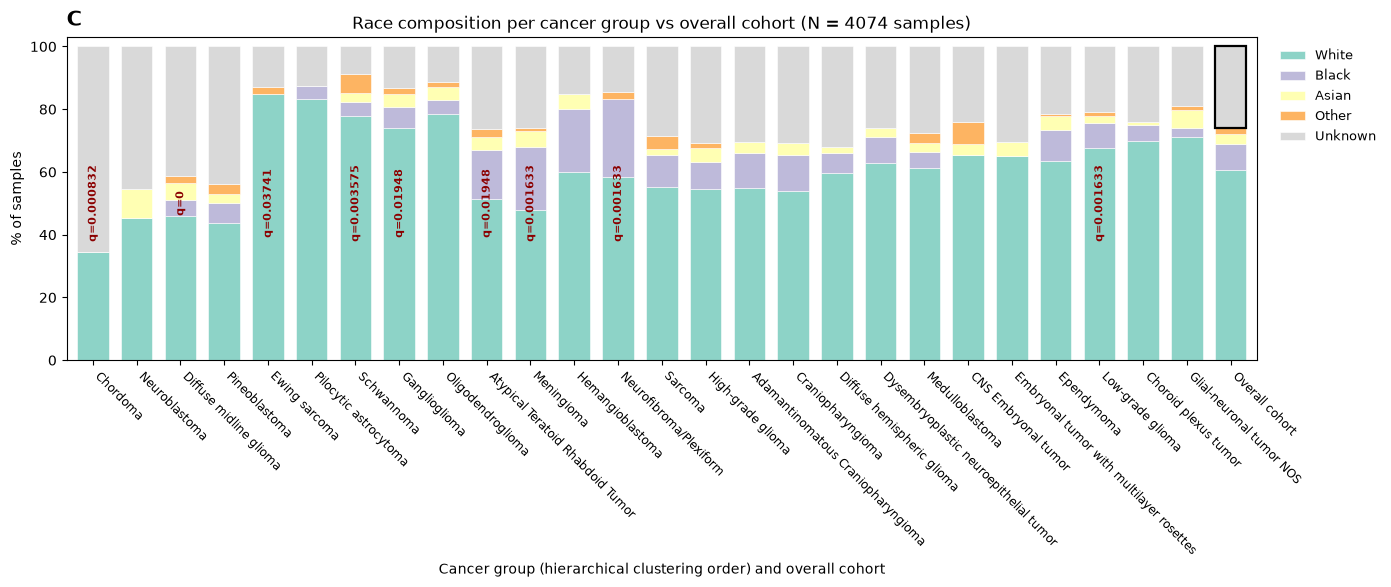

In [3]:
# Panel 3.C — Race composition per cancer group vs overall cohort
# context/figure_instructions/fig_clinical_association.md
# Group order: hierarchical clustering (complete linkage, Euclidean) on per-CG
# race proportion vectors (user decision 2026-08-02), NOT alphabetical.
%matplotlib inline
from scipy.cluster.hierarchy import linkage, leaves_list
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest, chi2_contingency, fisher_exact, chisquare
from scipy.stats import kruskal, mannwhitneyu, spearmanr
import statsmodels.stats.multitest as smm

PATIENT_FILE = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_patient_attributes.txt"
SAMPLE_FILE  = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_sample_attributes.txt"
RESULTS_CSV  = "/home/alon/menow_home_ass/notebooks/clinical_associations/clinical_associations_results.csv"

pat = pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                  dtype={"AGE": float, "AGE_IN_DAYS": float,
                         "OS_MONTHS": float, "EFS_MONTHS": float})
smp = pd.read_csv(SAMPLE_FILE, sep="\t", header=4)
df = pat.merge(smp, on="PATIENT_ID", how="inner")   # 4312 merged rows

df["RACE"] = df["RACE"].fillna("Unknown").replace({"Not Reported": "Unknown",
                                                   "Reported Unknown": "Unknown"})
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].fillna("Unknown")
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].replace("Not Reported", "Unknown")
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].replace("None documented", "No predisposition")
for col in ["SEX", "CANCER_GROUP", "CANCER_PREDISPOSITIONS", "RACE"]:
    if col in df.columns:
        df[col] = df[col].astype(str)
df = df[df["CANCER_GROUP"].notna() & (df["CANCER_GROUP"] != "nan")].copy()  # 4074 samples

race_group_map = {
    "White": "White",
    "Black or African American": "Black",
    "Asian": "Asian",
    "More Than One Race": "Other",
    "Other": "Other",
    "American Indian or Alaska Native": "Other",
    "Native Hawaiian or Other Pacific Islander": "Other",
    "Unknown": "Unknown",
}
df["RACE_GROUP"] = df["RACE"].map(race_group_map).fillna("Other")

def sig_star(q):
    if q < 0.001:
        return "***"
    if q < 0.01:
        return "**"
    if q < 0.05:
        return "*"
    return "ns"

def check_fdr(fam, records):
    """records: list of (group, q). Assert q matches CSV FDR_WithinFamily."""
    csv_fdr = pd.read_csv(RESULTS_CSV)
    csv_map = csv_fdr[csv_fdr["Comparison"] == fam].set_index("Group")["FDR_WithinFamily"]
    bad = [(g, q, float(csv_map.loc[g])) for g, q in records
           if g in csv_map.index and abs(float(q) - float(csv_map.loc[g])) > 1e-6]
    if bad:
        print("  !! FDR q vs CSV MISMATCH:", bad)
    else:
        print("  FDR q matches clinical_associations_results.csv")


print("3.C")
race_order = ["White", "Black", "Asian", "Other", "Unknown"]
overall_race = df["RACE_GROUP"].value_counts()
for cat in race_order:
    if cat not in overall_race.index:
        overall_race[cat] = 0
overall_race = overall_race[race_order]
overall_props = overall_race / overall_race.sum()
n_overall = int(overall_race.sum())
print("Overall cohort (N=%d): %s" % (n_overall,
    ", ".join("%s %d (%.1f%%)" % (c, int(overall_race[c]), overall_props[c] * 100) for c in race_order)))

rows = []
for group in sorted(df["CANCER_GROUP"].unique()):
    g = df[df["CANCER_GROUP"] == group]
    n = len(g)
    if n < 20:
        continue
    within = g["RACE_GROUP"].value_counts()
    for cat in race_order:
        if cat not in within.index:
            within[cat] = 0
    within = within[race_order]
    obs = within.values.astype(float)
    exp = (overall_props.values * n).astype(float)
    mask = exp > 0
    chi2v, p = chisquare(f_obs=obs[mask], f_exp=exp[mask])
    rows.append({"Group": group, "N": n, "p": round(p, 6), "w": within})
qs = smm.multipletests(np.array([r["p"] for r in rows]), method="fdr_bh")[1]
for r, q in zip(rows, qs):
    r["q"] = q
check_fdr("Race distribution", [(r["Group"], r["q"]) for r in rows])

# hierarchical clustering ordering of the 26 per-CG race proportion vectors
props = np.array([(r["w"] / r["N"]).values for r in rows])
Z = linkage(props, method="complete", metric="euclidean")
order = list(leaves_list(Z))
rows_ord = [rows[i] for i in order]

n_sig = sum(1 for r in rows if r["q"] < 0.05)
print("%d groups tested (n>=20); %d FDR-significant (q<0.05)" % (len(rows), n_sig))
for r in rows_ord:
    if r["q"] < 0.05:
        w = (r["w"] / r["N"] * 100).values
        print("  %s: q=%.4g  W/B/A/O/U=%.1f/%.1f/%.1f/%.1f/%.1f" % (
            r["Group"], r["q"], w[0], w[1], w[2], w[3], w[4]))

set3 = ["#8DD3C7", "#BEBADA", "#FFFFB3", "#FDB462", "#D9D9D9"]
fig, ax = plt.subplots(figsize=(14, 6))
labels = [r["Group"] for r in rows_ord] + ["Overall cohort"]
xpos = np.arange(len(labels))
bottom = np.zeros(len(labels))
for i, cat in enumerate(race_order):
    vals = np.array([r["w"][cat] / r["N"] * 100 for r in rows_ord] + [overall_props[cat] * 100])
    bars = ax.bar(xpos, vals, bottom=bottom, width=0.72, color=set3[i],
                  label=cat, edgecolor="white", linewidth=0.4)
    if cat == "Unknown":
        bars[-1].set_edgecolor("black")          # overall-cohort reference bar outline
        bars[-1].set_linewidth(1.6)
    bottom += vals
for xi, r in zip(xpos[: len(rows_ord)], rows_ord):
    if r["q"] < 0.05:
        ax.text(xi, bottom[xi] / 2, "q=%.4g" % r["q"], rotation=90,
                va="center", ha="center", fontsize=8, color="darkred", fontweight="bold")
ax.set_xticks(xpos)
ax.set_xticklabels(labels, rotation=-45, ha="left", fontsize=8.5)
ax.set_xlim(-0.6, len(labels) - 0.4)
ax.set_ylim(0, 103)
ax.set_xlabel("Cancer group (hierarchical clustering order) and overall cohort")
ax.set_ylabel("% of samples")
ax.set_title("Race composition per cancer group vs overall cohort (N = %d samples)" % n_overall)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=9)
ax.text(0.0, 1.02, "C", transform=ax.transAxes, fontsize=15, fontweight="bold",
        va="bottom", ha="left")
fig.tight_layout()
plt.show()


3.D
  FDR q matches clinical_associations_results.csv
N=3800 | Kruskal-Wallis H=826.74 p=2.756e-158 epsilon2=0.2124 | 14/26 groups FDR-significant
  Embryonal tumor with multilayer rosettes: N=23  p=0  q=0.0000  ***
  High-grade glioma: N=475  p=0  q=0.0000  ***
  Meningioma: N=100  p=0  q=0.0000  ***
  Oligodendroglioma: N=70  p=0  q=0.0000  ***
  Ependymoma: N=340  p=0  q=0.0000  ***
  Glial-neuronal tumor NOS: N=69  p=0.01643  q=0.0296  *
  Choroid plexus tumor: N=99  p=0  q=0.0000  ***
  Neurofibroma/Plexiform: N=48  p=4.4e-05  q=0.0001  ***
  Schwannoma: N=68  p=0  q=0.0000  ***
  Atypical Teratoid Rhabdoid Tumor: N=152  p=0  q=0.0000  ***
  Dysembryoplastic neuroepithelial tumor: N=73  p=0.001078  q=0.0021  **
  Hemangioblastoma: N=20  p=0  q=0.0000  ***
  Diffuse hemispheric glioma: N=33  p=0  q=0.0000  ***
  Neuroblastoma: N=22  p=0  q=0.0000  ***


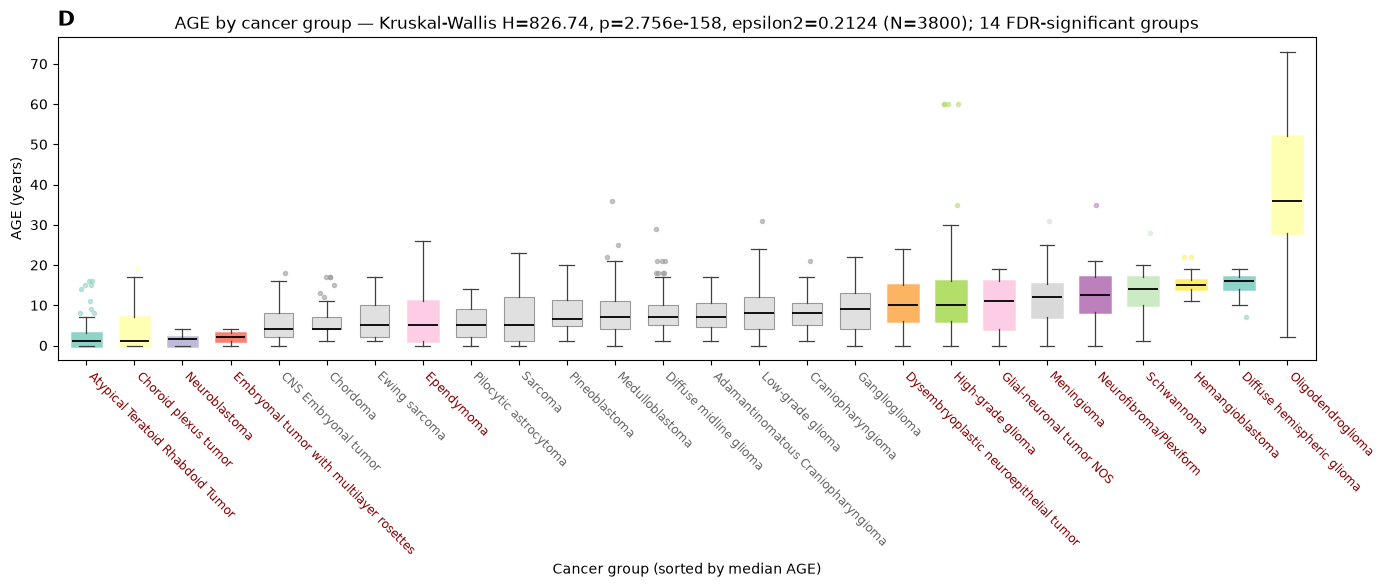

In [4]:
# Panel 3.D — AGE distribution by cancer group
# context/figure_instructions/fig_clinical_association.md
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest, chi2_contingency, fisher_exact, chisquare
from scipy.stats import kruskal, mannwhitneyu, spearmanr
import statsmodels.stats.multitest as smm

PATIENT_FILE = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_patient_attributes.txt"
SAMPLE_FILE  = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_sample_attributes.txt"
RESULTS_CSV  = "/home/alon/menow_home_ass/notebooks/clinical_associations/clinical_associations_results.csv"

pat = pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                  dtype={"AGE": float, "AGE_IN_DAYS": float,
                         "OS_MONTHS": float, "EFS_MONTHS": float})
smp = pd.read_csv(SAMPLE_FILE, sep="\t", header=4)
df = pat.merge(smp, on="PATIENT_ID", how="inner")   # 4312 merged rows

df["RACE"] = df["RACE"].fillna("Unknown").replace({"Not Reported": "Unknown",
                                                   "Reported Unknown": "Unknown"})
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].fillna("Unknown")
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].replace("Not Reported", "Unknown")
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].replace("None documented", "No predisposition")
for col in ["SEX", "CANCER_GROUP", "CANCER_PREDISPOSITIONS", "RACE"]:
    if col in df.columns:
        df[col] = df[col].astype(str)
df = df[df["CANCER_GROUP"].notna() & (df["CANCER_GROUP"] != "nan")].copy()  # 4074 samples

race_group_map = {
    "White": "White",
    "Black or African American": "Black",
    "Asian": "Asian",
    "More Than One Race": "Other",
    "Other": "Other",
    "American Indian or Alaska Native": "Other",
    "Native Hawaiian or Other Pacific Islander": "Other",
    "Unknown": "Unknown",
}
df["RACE_GROUP"] = df["RACE"].map(race_group_map).fillna("Other")

def sig_star(q):
    if q < 0.001:
        return "***"
    if q < 0.01:
        return "**"
    if q < 0.05:
        return "*"
    return "ns"

def check_fdr(fam, records):
    """records: list of (group, q). Assert q matches CSV FDR_WithinFamily."""
    csv_fdr = pd.read_csv(RESULTS_CSV)
    csv_map = csv_fdr[csv_fdr["Comparison"] == fam].set_index("Group")["FDR_WithinFamily"]
    bad = [(g, q, float(csv_map.loc[g])) for g, q in records
           if g in csv_map.index and abs(float(q) - float(csv_map.loc[g])) > 1e-6]
    if bad:
        print("  !! FDR q vs CSV MISMATCH:", bad)
    else:
        print("  FDR q matches clinical_associations_results.csv")


print("3.D")
sub = df[["AGE", "CANCER_GROUP"]].dropna()
keep = sub["CANCER_GROUP"].value_counts()
keep = keep[keep >= 20].index
sub = sub[sub["CANCER_GROUP"].isin(keep)]

# Global Kruskal-Wallis
groups_data = [sub[sub["CANCER_GROUP"] == g]["AGE"].values for g in sub["CANCER_GROUP"].unique()]
h, p_kw = kruskal(*groups_data)
n = len(sub)
k = len(groups_data)
eps_sq = (h - k + 1) / (n - k)

# Per-group Mann-Whitney (group vs all others); FDR over the full family
# INCLUDING the KW global row, on p rounded to 6 dp (reproduces the CSV exactly)
records = [("global", n, round(p_kw, 6))]
for g in sub["CANCER_GROUP"].unique():
    gv = sub[sub["CANCER_GROUP"] == g]["AGE"].values
    ov = sub[sub["CANCER_GROUP"] != g]["AGE"].values
    u, p = mannwhitneyu(gv, ov, alternative="two-sided")
    records.append((g, len(gv), round(p, 6)))
pvals = np.array([r[2] for r in records])
qs = smm.multipletests(pvals, method="fdr_bh")[1]
res = {}
for (g, gn, p), q in zip(records, qs):
    res[g] = {"n": gn, "p": p, "q": q}

check_fdr("AGE x CANCER_GROUP", [(g, res[g]["q"]) for g in res])
n_sig = sum(1 for g in res if g != "global" and res[g]["q"] < 0.05)
print("N=%d | Kruskal-Wallis H=%.2f p=%.4g epsilon2=%.4f | %d/%d groups FDR-significant" % (
    n, h, p_kw, eps_sq, n_sig, len(res) - 1))
for g, r in res.items():
    if g == "global":
        continue
    if r["q"] < 0.05:
        print("  %s: N=%d  p=%.4g  q=%.4f  %s" % (g, r["n"], r["p"], r["q"], sig_star(r["q"])))

# order x by median value; significant CGs emphasised (bold, full colour)
order = sub.groupby("CANCER_GROUP")["AGE"].median().sort_values().index.tolist()
data = [sub[sub["CANCER_GROUP"] == g]["AGE"].values for g in order]
set3 = ["#8DD3C7", "#FFFFB3", "#BEBADA", "#FB8072", "#80B1D3", "#FDB462",
        "#B3DE69", "#FCCDE5", "#D9D9D9", "#BC80BD", "#CCEBC5", "#FFED6F"]

fig, ax = plt.subplots(figsize=(14, 6))
xpos = np.arange(len(order))
boxes = ax.boxplot(data, positions=xpos, widths=0.62, patch_artist=True,
                   showfliers=False,
                   medianprops=dict(color="black", lw=1.3),
                   whiskerprops=dict(color="0.25", lw=0.9),
                   capprops=dict(color="0.25", lw=0.9),
                   boxprops=dict(lw=0.9))
for i, g in enumerate(order):
    sig = res[g]["q"] < 0.05
    col = set3[i % len(set3)]
    boxes["boxes"][i].set_facecolor(col if sig else "0.88")
    boxes["boxes"][i].set_edgecolor(col if sig else "0.6")
    boxes["boxes"][i].set_linewidth(1.8 if sig else 0.8)
    vals = data[i]
    q1, q3 = np.percentile(vals, [25, 75])
    iqr = q3 - q1
    out = vals[(vals < q1 - 1.5 * iqr) | (vals > q3 + 1.5 * iqr)]
    rng = np.random.default_rng(42 + i)
    ax.scatter(i + rng.uniform(-0.16, 0.16, len(out)), out, s=9,
               alpha=0.55, color=col if sig else "0.6", zorder=3)
ax.set_xticks(xpos)
ax.set_xticklabels(order, rotation=-45, ha="left", fontsize=8.5)
for tk, g in zip(ax.get_xticklabels(), order):
    tk.set_color("darkred" if res[g]["q"] < 0.05 else "0.4")
ax.set_xlim(-0.6, len(order) - 0.4)
ax.set_xlabel("Cancer group (sorted by median AGE)")
ax.set_ylabel("AGE (years)")
ax.set_title("AGE by cancer group — Kruskal-Wallis H=%.2f, p=%.4g, epsilon2=%.4f (N=%d); %d FDR-significant groups" % (
    h, p_kw, eps_sq, n, n_sig))
ax.text(0.0, 1.02, "D", transform=ax.transAxes, fontsize=15, fontweight="bold",
        va="bottom", ha="left")
fig.tight_layout()
plt.show()


3.E
  FDR q matches clinical_associations_results.csv
N=2538 | Kruskal-Wallis H=100.09 p=1.216e-12 epsilon2=0.0318 | 6/21 groups FDR-significant
  High-grade glioma: N=271  p=3e-06  q=0.0000  ***
  Low-grade glioma: N=521  p=0.01318  q=0.0414  *
  Ependymoma: N=236  p=0.000108  q=0.0005  ***
  Adamantinomatous Craniopharyngioma: N=84  p=3.4e-05  q=0.0002  ***
  Diffuse midline glioma: N=367  p=0  q=0.0000  ***
  Neurofibroma/Plexiform: N=38  p=0.003366  q=0.0123  *


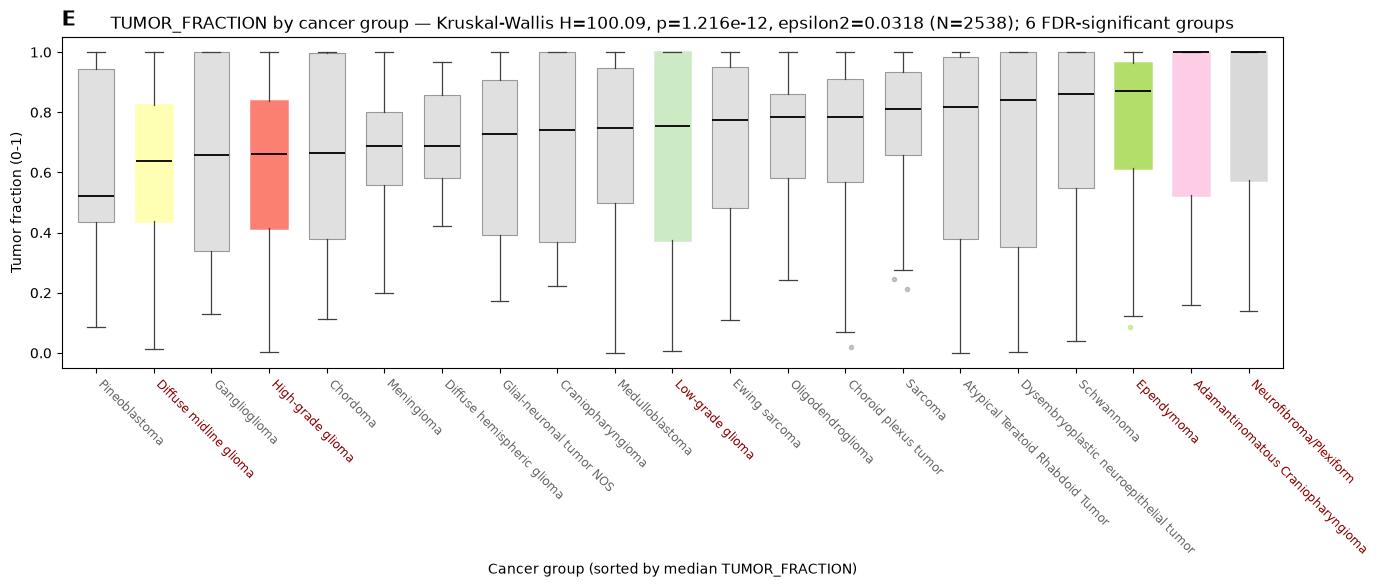

In [5]:
# Panel 3.E — TUMOR_FRACTION distribution by cancer group
# context/figure_instructions/fig_clinical_association.md
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest, chi2_contingency, fisher_exact, chisquare
from scipy.stats import kruskal, mannwhitneyu, spearmanr
import statsmodels.stats.multitest as smm

PATIENT_FILE = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_patient_attributes.txt"
SAMPLE_FILE  = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_sample_attributes.txt"
RESULTS_CSV  = "/home/alon/menow_home_ass/notebooks/clinical_associations/clinical_associations_results.csv"

pat = pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                  dtype={"AGE": float, "AGE_IN_DAYS": float,
                         "OS_MONTHS": float, "EFS_MONTHS": float})
smp = pd.read_csv(SAMPLE_FILE, sep="\t", header=4)
df = pat.merge(smp, on="PATIENT_ID", how="inner")   # 4312 merged rows

df["RACE"] = df["RACE"].fillna("Unknown").replace({"Not Reported": "Unknown",
                                                   "Reported Unknown": "Unknown"})
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].fillna("Unknown")
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].replace("Not Reported", "Unknown")
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].replace("None documented", "No predisposition")
for col in ["SEX", "CANCER_GROUP", "CANCER_PREDISPOSITIONS", "RACE"]:
    if col in df.columns:
        df[col] = df[col].astype(str)
df = df[df["CANCER_GROUP"].notna() & (df["CANCER_GROUP"] != "nan")].copy()  # 4074 samples

race_group_map = {
    "White": "White",
    "Black or African American": "Black",
    "Asian": "Asian",
    "More Than One Race": "Other",
    "Other": "Other",
    "American Indian or Alaska Native": "Other",
    "Native Hawaiian or Other Pacific Islander": "Other",
    "Unknown": "Unknown",
}
df["RACE_GROUP"] = df["RACE"].map(race_group_map).fillna("Other")

def sig_star(q):
    if q < 0.001:
        return "***"
    if q < 0.01:
        return "**"
    if q < 0.05:
        return "*"
    return "ns"

def check_fdr(fam, records):
    """records: list of (group, q). Assert q matches CSV FDR_WithinFamily."""
    csv_fdr = pd.read_csv(RESULTS_CSV)
    csv_map = csv_fdr[csv_fdr["Comparison"] == fam].set_index("Group")["FDR_WithinFamily"]
    bad = [(g, q, float(csv_map.loc[g])) for g, q in records
           if g in csv_map.index and abs(float(q) - float(csv_map.loc[g])) > 1e-6]
    if bad:
        print("  !! FDR q vs CSV MISMATCH:", bad)
    else:
        print("  FDR q matches clinical_associations_results.csv")


print("3.E")
sub = df[["TUMOR_FRACTION", "CANCER_GROUP"]].dropna()
keep = sub["CANCER_GROUP"].value_counts()
keep = keep[keep >= 20].index
sub = sub[sub["CANCER_GROUP"].isin(keep)]

# Global Kruskal-Wallis
groups_data = [sub[sub["CANCER_GROUP"] == g]["TUMOR_FRACTION"].values for g in sub["CANCER_GROUP"].unique()]
h, p_kw = kruskal(*groups_data)
n = len(sub)
k = len(groups_data)
eps_sq = (h - k + 1) / (n - k)

# Per-group Mann-Whitney (group vs all others); FDR over the full family
# INCLUDING the KW global row, on p rounded to 6 dp (reproduces the CSV exactly)
records = [("global", n, round(p_kw, 6))]
for g in sub["CANCER_GROUP"].unique():
    gv = sub[sub["CANCER_GROUP"] == g]["TUMOR_FRACTION"].values
    ov = sub[sub["CANCER_GROUP"] != g]["TUMOR_FRACTION"].values
    u, p = mannwhitneyu(gv, ov, alternative="two-sided")
    records.append((g, len(gv), round(p, 6)))
pvals = np.array([r[2] for r in records])
qs = smm.multipletests(pvals, method="fdr_bh")[1]
res = {}
for (g, gn, p), q in zip(records, qs):
    res[g] = {"n": gn, "p": p, "q": q}

check_fdr("TUMOR_FRACTION x CANCER_GROUP", [(g, res[g]["q"]) for g in res])
n_sig = sum(1 for g in res if g != "global" and res[g]["q"] < 0.05)
print("N=%d | Kruskal-Wallis H=%.2f p=%.4g epsilon2=%.4f | %d/%d groups FDR-significant" % (
    n, h, p_kw, eps_sq, n_sig, len(res) - 1))
for g, r in res.items():
    if g == "global":
        continue
    if r["q"] < 0.05:
        print("  %s: N=%d  p=%.4g  q=%.4f  %s" % (g, r["n"], r["p"], r["q"], sig_star(r["q"])))

# order x by median value; significant CGs emphasised (bold, full colour)
order = sub.groupby("CANCER_GROUP")["TUMOR_FRACTION"].median().sort_values().index.tolist()
data = [sub[sub["CANCER_GROUP"] == g]["TUMOR_FRACTION"].values for g in order]
set3 = ["#8DD3C7", "#FFFFB3", "#BEBADA", "#FB8072", "#80B1D3", "#FDB462",
        "#B3DE69", "#FCCDE5", "#D9D9D9", "#BC80BD", "#CCEBC5", "#FFED6F"]

fig, ax = plt.subplots(figsize=(14, 6))
xpos = np.arange(len(order))
boxes = ax.boxplot(data, positions=xpos, widths=0.62, patch_artist=True,
                   showfliers=False,
                   medianprops=dict(color="black", lw=1.3),
                   whiskerprops=dict(color="0.25", lw=0.9),
                   capprops=dict(color="0.25", lw=0.9),
                   boxprops=dict(lw=0.9))
for i, g in enumerate(order):
    sig = res[g]["q"] < 0.05
    col = set3[i % len(set3)]
    boxes["boxes"][i].set_facecolor(col if sig else "0.88")
    boxes["boxes"][i].set_edgecolor(col if sig else "0.6")
    boxes["boxes"][i].set_linewidth(1.8 if sig else 0.8)
    vals = data[i]
    q1, q3 = np.percentile(vals, [25, 75])
    iqr = q3 - q1
    out = vals[(vals < q1 - 1.5 * iqr) | (vals > q3 + 1.5 * iqr)]
    rng = np.random.default_rng(42 + i)
    ax.scatter(i + rng.uniform(-0.16, 0.16, len(out)), out, s=9,
               alpha=0.55, color=col if sig else "0.6", zorder=3)
ax.set_xticks(xpos)
ax.set_xticklabels(order, rotation=-45, ha="left", fontsize=8.5)
for tk, g in zip(ax.get_xticklabels(), order):
    tk.set_color("darkred" if res[g]["q"] < 0.05 else "0.4")
ax.set_xlim(-0.6, len(order) - 0.4)
ax.set_xlabel("Cancer group (sorted by median TUMOR_FRACTION)")
ax.set_ylabel("Tumor fraction (0-1)")
ax.set_title("TUMOR_FRACTION by cancer group — Kruskal-Wallis H=%.2f, p=%.4g, epsilon2=%.4f (N=%d); %d FDR-significant groups" % (
    h, p_kw, eps_sq, n, n_sig))
ax.text(0.0, 1.02, "E", transform=ax.transAxes, fontsize=15, fontweight="bold",
        va="bottom", ha="left")
fig.tight_layout()
plt.show()


3.F
  FDR q matches clinical_associations_results.csv
N=2591 | Kruskal-Wallis H=54.50 p=4.868e-05 epsilon2=0.0134 | 4/21 groups FDR-significant
  Low-grade glioma: N=542  p=0.01108  q=0.0488  *
  Choroid plexus tumor: N=68  p=0.002678  q=0.0265  *
  Chordoma: N=22  p=0.003618  q=0.0265  *
  Dysembryoplastic neuroepithelial tumor: N=48  p=0.009897  q=0.0488  *


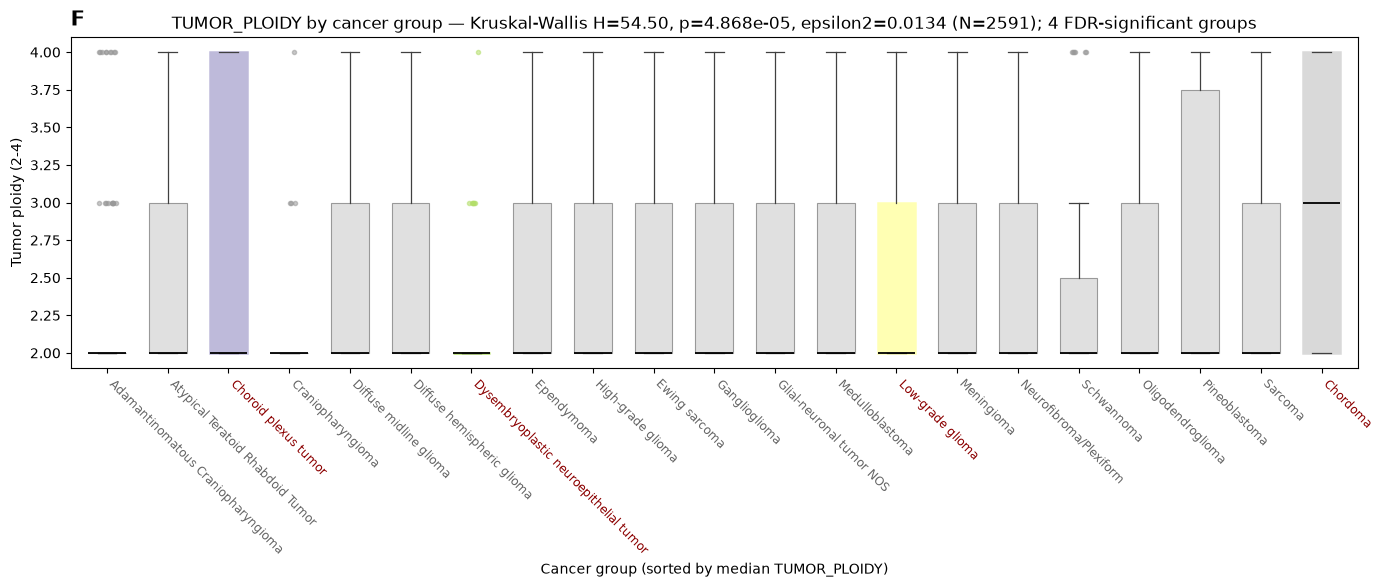

In [6]:
# Panel 3.F — TUMOR_PLOIDY distribution by cancer group
# context/figure_instructions/fig_clinical_association.md
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest, chi2_contingency, fisher_exact, chisquare
from scipy.stats import kruskal, mannwhitneyu, spearmanr
import statsmodels.stats.multitest as smm

PATIENT_FILE = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_patient_attributes.txt"
SAMPLE_FILE  = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_sample_attributes.txt"
RESULTS_CSV  = "/home/alon/menow_home_ass/notebooks/clinical_associations/clinical_associations_results.csv"

pat = pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                  dtype={"AGE": float, "AGE_IN_DAYS": float,
                         "OS_MONTHS": float, "EFS_MONTHS": float})
smp = pd.read_csv(SAMPLE_FILE, sep="\t", header=4)
df = pat.merge(smp, on="PATIENT_ID", how="inner")   # 4312 merged rows

df["RACE"] = df["RACE"].fillna("Unknown").replace({"Not Reported": "Unknown",
                                                   "Reported Unknown": "Unknown"})
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].fillna("Unknown")
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].replace("Not Reported", "Unknown")
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].replace("None documented", "No predisposition")
for col in ["SEX", "CANCER_GROUP", "CANCER_PREDISPOSITIONS", "RACE"]:
    if col in df.columns:
        df[col] = df[col].astype(str)
df = df[df["CANCER_GROUP"].notna() & (df["CANCER_GROUP"] != "nan")].copy()  # 4074 samples

race_group_map = {
    "White": "White",
    "Black or African American": "Black",
    "Asian": "Asian",
    "More Than One Race": "Other",
    "Other": "Other",
    "American Indian or Alaska Native": "Other",
    "Native Hawaiian or Other Pacific Islander": "Other",
    "Unknown": "Unknown",
}
df["RACE_GROUP"] = df["RACE"].map(race_group_map).fillna("Other")

def sig_star(q):
    if q < 0.001:
        return "***"
    if q < 0.01:
        return "**"
    if q < 0.05:
        return "*"
    return "ns"

def check_fdr(fam, records):
    """records: list of (group, q). Assert q matches CSV FDR_WithinFamily."""
    csv_fdr = pd.read_csv(RESULTS_CSV)
    csv_map = csv_fdr[csv_fdr["Comparison"] == fam].set_index("Group")["FDR_WithinFamily"]
    bad = [(g, q, float(csv_map.loc[g])) for g, q in records
           if g in csv_map.index and abs(float(q) - float(csv_map.loc[g])) > 1e-6]
    if bad:
        print("  !! FDR q vs CSV MISMATCH:", bad)
    else:
        print("  FDR q matches clinical_associations_results.csv")


print("3.F")
sub = df[["TUMOR_PLOIDY", "CANCER_GROUP"]].dropna()
keep = sub["CANCER_GROUP"].value_counts()
keep = keep[keep >= 20].index
sub = sub[sub["CANCER_GROUP"].isin(keep)]

# Global Kruskal-Wallis
groups_data = [sub[sub["CANCER_GROUP"] == g]["TUMOR_PLOIDY"].values for g in sub["CANCER_GROUP"].unique()]
h, p_kw = kruskal(*groups_data)
n = len(sub)
k = len(groups_data)
eps_sq = (h - k + 1) / (n - k)

# Per-group Mann-Whitney (group vs all others); FDR over the full family
# INCLUDING the KW global row, on p rounded to 6 dp (reproduces the CSV exactly)
records = [("global", n, round(p_kw, 6))]
for g in sub["CANCER_GROUP"].unique():
    gv = sub[sub["CANCER_GROUP"] == g]["TUMOR_PLOIDY"].values
    ov = sub[sub["CANCER_GROUP"] != g]["TUMOR_PLOIDY"].values
    u, p = mannwhitneyu(gv, ov, alternative="two-sided")
    records.append((g, len(gv), round(p, 6)))
pvals = np.array([r[2] for r in records])
qs = smm.multipletests(pvals, method="fdr_bh")[1]
res = {}
for (g, gn, p), q in zip(records, qs):
    res[g] = {"n": gn, "p": p, "q": q}

check_fdr("TUMOR_PLOIDY x CANCER_GROUP", [(g, res[g]["q"]) for g in res])
n_sig = sum(1 for g in res if g != "global" and res[g]["q"] < 0.05)
print("N=%d | Kruskal-Wallis H=%.2f p=%.4g epsilon2=%.4f | %d/%d groups FDR-significant" % (
    n, h, p_kw, eps_sq, n_sig, len(res) - 1))
for g, r in res.items():
    if g == "global":
        continue
    if r["q"] < 0.05:
        print("  %s: N=%d  p=%.4g  q=%.4f  %s" % (g, r["n"], r["p"], r["q"], sig_star(r["q"])))

# order x by median value; significant CGs emphasised (bold, full colour)
order = sub.groupby("CANCER_GROUP")["TUMOR_PLOIDY"].median().sort_values().index.tolist()
data = [sub[sub["CANCER_GROUP"] == g]["TUMOR_PLOIDY"].values for g in order]
set3 = ["#8DD3C7", "#FFFFB3", "#BEBADA", "#FB8072", "#80B1D3", "#FDB462",
        "#B3DE69", "#FCCDE5", "#D9D9D9", "#BC80BD", "#CCEBC5", "#FFED6F"]

fig, ax = plt.subplots(figsize=(14, 6))
xpos = np.arange(len(order))
boxes = ax.boxplot(data, positions=xpos, widths=0.62, patch_artist=True,
                   showfliers=False,
                   medianprops=dict(color="black", lw=1.3),
                   whiskerprops=dict(color="0.25", lw=0.9),
                   capprops=dict(color="0.25", lw=0.9),
                   boxprops=dict(lw=0.9))
for i, g in enumerate(order):
    sig = res[g]["q"] < 0.05
    col = set3[i % len(set3)]
    boxes["boxes"][i].set_facecolor(col if sig else "0.88")
    boxes["boxes"][i].set_edgecolor(col if sig else "0.6")
    boxes["boxes"][i].set_linewidth(1.8 if sig else 0.8)
    vals = data[i]
    q1, q3 = np.percentile(vals, [25, 75])
    iqr = q3 - q1
    out = vals[(vals < q1 - 1.5 * iqr) | (vals > q3 + 1.5 * iqr)]
    rng = np.random.default_rng(42 + i)
    ax.scatter(i + rng.uniform(-0.16, 0.16, len(out)), out, s=9,
               alpha=0.55, color=col if sig else "0.6", zorder=3)
ax.set_xticks(xpos)
ax.set_xticklabels(order, rotation=-45, ha="left", fontsize=8.5)
for tk, g in zip(ax.get_xticklabels(), order):
    tk.set_color("darkred" if res[g]["q"] < 0.05 else "0.4")
ax.set_xlim(-0.6, len(order) - 0.4)
ax.set_xlabel("Cancer group (sorted by median TUMOR_PLOIDY)")
ax.set_ylabel("Tumor ploidy (2-4)")
ax.set_title("TUMOR_PLOIDY by cancer group — Kruskal-Wallis H=%.2f, p=%.4g, epsilon2=%.4f (N=%d); %d FDR-significant groups" % (
    h, p_kw, eps_sq, n, n_sig))
ax.text(0.0, 1.02, "F", transform=ax.transAxes, fontsize=15, fontweight="bold",
        va="bottom", ha="left")
fig.tight_layout()
plt.show()


3.G
  FDR q matches clinical_associations_results.csv
AGE x TUMOR_FRACTION: Spearman rho=-0.0978  p=3.618e-07  q=0.0000  N=2694
AGE x TUMOR_PLOIDY: Spearman rho=0.0437  p=0.02189  q=0.0219  N=2751
TUMOR_FRACTION x TUMOR_PLOIDY: Spearman rho=-0.0855  p=7.364e-06  q=0.0000  N=2744
Significant p-values with no observed trends (|rho|<0.1), possibly due to the high sample amount.


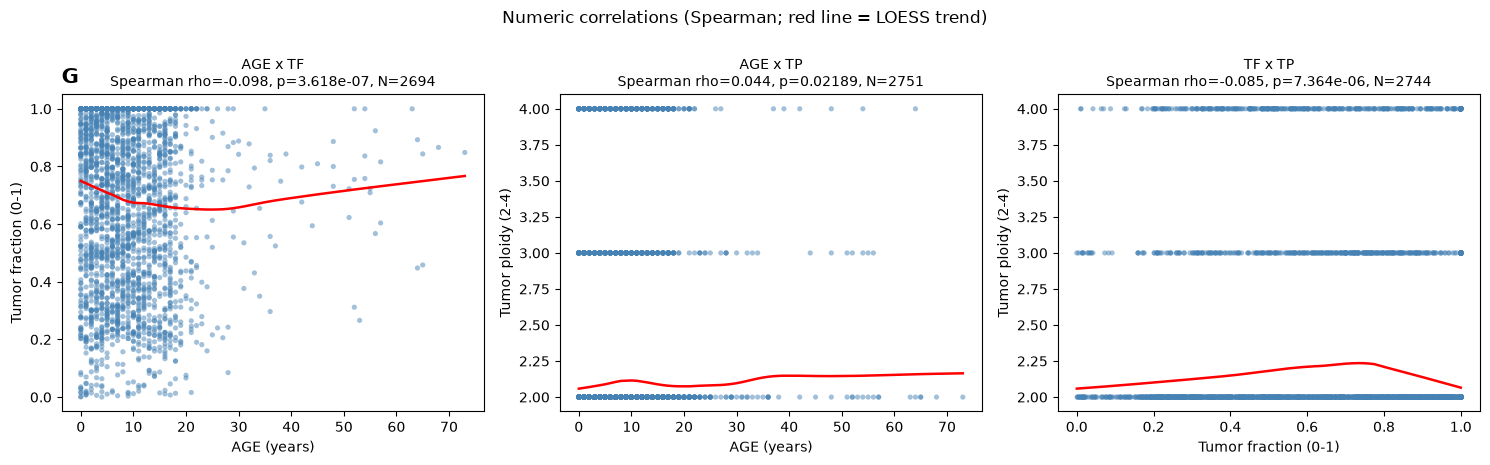

In [7]:
# Panel 3.G — Spearman correlations (AGE x TF, AGE x TP, TF x TP)
# context/figure_instructions/fig_clinical_association.md
# Spearman rank correlations; Pearson r is computed ad-hoc in Panel H.
%matplotlib inline
import statsmodels.nonparametric.smoothers_lowess as smlowess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest, chi2_contingency, fisher_exact, chisquare
from scipy.stats import kruskal, mannwhitneyu, spearmanr
import statsmodels.stats.multitest as smm

PATIENT_FILE = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_patient_attributes.txt"
SAMPLE_FILE  = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_sample_attributes.txt"
RESULTS_CSV  = "/home/alon/menow_home_ass/notebooks/clinical_associations/clinical_associations_results.csv"

pat = pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                  dtype={"AGE": float, "AGE_IN_DAYS": float,
                         "OS_MONTHS": float, "EFS_MONTHS": float})
smp = pd.read_csv(SAMPLE_FILE, sep="\t", header=4)
df = pat.merge(smp, on="PATIENT_ID", how="inner")   # 4312 merged rows

df["RACE"] = df["RACE"].fillna("Unknown").replace({"Not Reported": "Unknown",
                                                   "Reported Unknown": "Unknown"})
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].fillna("Unknown")
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].replace("Not Reported", "Unknown")
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].replace("None documented", "No predisposition")
for col in ["SEX", "CANCER_GROUP", "CANCER_PREDISPOSITIONS", "RACE"]:
    if col in df.columns:
        df[col] = df[col].astype(str)
df = df[df["CANCER_GROUP"].notna() & (df["CANCER_GROUP"] != "nan")].copy()  # 4074 samples

race_group_map = {
    "White": "White",
    "Black or African American": "Black",
    "Asian": "Asian",
    "More Than One Race": "Other",
    "Other": "Other",
    "American Indian or Alaska Native": "Other",
    "Native Hawaiian or Other Pacific Islander": "Other",
    "Unknown": "Unknown",
}
df["RACE_GROUP"] = df["RACE"].map(race_group_map).fillna("Other")

def sig_star(q):
    if q < 0.001:
        return "***"
    if q < 0.01:
        return "**"
    if q < 0.05:
        return "*"
    return "ns"

def check_fdr(fam, records):
    """records: list of (group, q). Assert q matches CSV FDR_WithinFamily."""
    csv_fdr = pd.read_csv(RESULTS_CSV)
    csv_map = csv_fdr[csv_fdr["Comparison"] == fam].set_index("Group")["FDR_WithinFamily"]
    bad = [(g, q, float(csv_map.loc[g])) for g, q in records
           if g in csv_map.index and abs(float(q) - float(csv_map.loc[g])) > 1e-6]
    if bad:
        print("  !! FDR q vs CSV MISMATCH:", bad)
    else:
        print("  FDR q matches clinical_associations_results.csv")


print("3.G")
pairs = [
    ("AGE", "TUMOR_FRACTION", "AGE (years)", "Tumor fraction (0-1)"),
    ("AGE", "TUMOR_PLOIDY", "AGE (years)", "Tumor ploidy (2-4)"),
    ("TUMOR_FRACTION", "TUMOR_PLOIDY", "Tumor fraction (0-1)", "Tumor ploidy (2-4)"),
]
subtitles = ["AGE x TF", "AGE x TP", "TF x TP"]
results = []
for c1, c2, xlab, ylab in pairs:
    s = df[[c1, c2]].dropna()
    rho, p = spearmanr(s[c1], s[c2])
    results.append((c1, c2, rho, p, len(s)))

# FDR (BH) over the 3 Spearman p-values (rounded to 6 dp) to match the CSV
pvals = np.array([round(r[3], 6) for r in results])
qs = smm.multipletests(pvals, method="fdr_bh")[1]
# CSV stores one 'global' row per pair; disambiguate by N (sample count)
csv_fdr = pd.read_csv(RESULTS_CSV)
csv_corr = csv_fdr[csv_fdr["Comparison"] == "Numeric correlations"]
bad = []
for n, q in [(r[4], q) for r, q in zip(results, qs)]:
    row = csv_corr[csv_corr["N"] == n]
    if len(row) and abs(float(row["FDR_WithinFamily"].iloc[0]) - float(q)) > 1e-6:
        bad.append((n, q, float(row["FDR_WithinFamily"].iloc[0])))
if bad:
    print("  !! FDR q vs CSV MISMATCH:", bad)
else:
    print("  FDR q matches clinical_associations_results.csv")

for (c1, c2, rho, p, n), q in zip(results, qs):
    print("%s x %s: Spearman rho=%.4f  p=%.4g  q=%.4f  N=%d" % (c1, c2, rho, p, q, n))
print("Significant p-values with no observed trends (|rho|<0.1), possibly due to the high sample amount.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (c1, c2, xlab, ylab), (c1b, c2b, rho, p, n), q, st in zip(
        axes, pairs, results, qs, subtitles):
    s = df[[c1b, c2b]].dropna()
    x, y = s[c1b].values, s[c2b].values
    ax.scatter(x, y, s=14, alpha=0.5, color="steelblue", edgecolors="none", zorder=2)
    lo = smlowess.lowess(y, x, frac=2 / 3, it=3)
    ax.plot(lo[:, 0], lo[:, 1], color="red", lw=1.8, zorder=3)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title("%s\nSpearman rho=%.3f, p=%.4g, N=%d" % (st, rho, p, n), fontsize=10)
axes[0].text(0.0, 1.02, "G", transform=axes[0].transAxes, fontsize=15, fontweight="bold",
        va="bottom", ha="left")
fig.suptitle("Numeric correlations (Spearman; red line = LOESS trend)", y=1.0)
fig.tight_layout()
plt.show()


3.H
AGE x TUMOR_FRACTION: Pearson r=-0.0527  p=0.006262  N=2694
AGE x TUMOR_PLOIDY: Pearson r=0.0315  p=0.09856  N=2751
TUMOR_FRACTION x TUMOR_PLOIDY: Pearson r=-0.0645  p=0.0007172  N=2744
AGE x TP: p=0.0986 >= 0.05 -> not significant (ns); the other two pairs are significant.
Significant p-values with no observed trends (|r|<0.1), possibly due to the high sample amount.


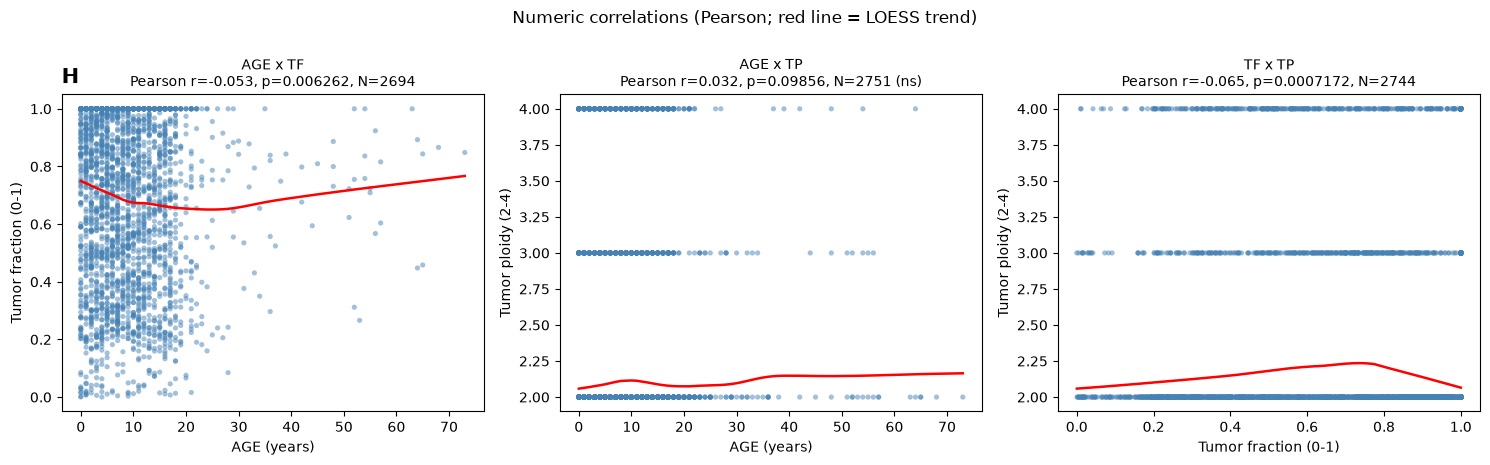

In [8]:
# Panel 3.H — Pearson correlations (AGE x TF, AGE x TP, TF x TP)
# context/figure_instructions/fig_clinical_association.md
# Pearson r, p, N for the same 3 pairs as Panel G (ad-hoc computation from the
# same merged table, same pairwise dropna; Pearson is not in the analysis notebook).
%matplotlib inline
from scipy.stats import pearsonr
import statsmodels.nonparametric.smoothers_lowess as smlowess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest, chi2_contingency, fisher_exact, chisquare
from scipy.stats import kruskal, mannwhitneyu, spearmanr
import statsmodels.stats.multitest as smm

PATIENT_FILE = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_patient_attributes.txt"
SAMPLE_FILE  = "/home/alon/menow_home_ass/PBTA_RNA/data_clinical_sample_attributes.txt"
RESULTS_CSV  = "/home/alon/menow_home_ass/notebooks/clinical_associations/clinical_associations_results.csv"

pat = pd.read_csv(PATIENT_FILE, sep="\t", header=4,
                  dtype={"AGE": float, "AGE_IN_DAYS": float,
                         "OS_MONTHS": float, "EFS_MONTHS": float})
smp = pd.read_csv(SAMPLE_FILE, sep="\t", header=4)
df = pat.merge(smp, on="PATIENT_ID", how="inner")   # 4312 merged rows

df["RACE"] = df["RACE"].fillna("Unknown").replace({"Not Reported": "Unknown",
                                                   "Reported Unknown": "Unknown"})
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].fillna("Unknown")
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].replace("Not Reported", "Unknown")
df["CANCER_PREDISPOSITIONS"] = df["CANCER_PREDISPOSITIONS"].replace("None documented", "No predisposition")
for col in ["SEX", "CANCER_GROUP", "CANCER_PREDISPOSITIONS", "RACE"]:
    if col in df.columns:
        df[col] = df[col].astype(str)
df = df[df["CANCER_GROUP"].notna() & (df["CANCER_GROUP"] != "nan")].copy()  # 4074 samples

race_group_map = {
    "White": "White",
    "Black or African American": "Black",
    "Asian": "Asian",
    "More Than One Race": "Other",
    "Other": "Other",
    "American Indian or Alaska Native": "Other",
    "Native Hawaiian or Other Pacific Islander": "Other",
    "Unknown": "Unknown",
}
df["RACE_GROUP"] = df["RACE"].map(race_group_map).fillna("Other")

def sig_star(q):
    if q < 0.001:
        return "***"
    if q < 0.01:
        return "**"
    if q < 0.05:
        return "*"
    return "ns"

def check_fdr(fam, records):
    """records: list of (group, q). Assert q matches CSV FDR_WithinFamily."""
    csv_fdr = pd.read_csv(RESULTS_CSV)
    csv_map = csv_fdr[csv_fdr["Comparison"] == fam].set_index("Group")["FDR_WithinFamily"]
    bad = [(g, q, float(csv_map.loc[g])) for g, q in records
           if g in csv_map.index and abs(float(q) - float(csv_map.loc[g])) > 1e-6]
    if bad:
        print("  !! FDR q vs CSV MISMATCH:", bad)
    else:
        print("  FDR q matches clinical_associations_results.csv")


print("3.H")
pairs = [
    ("AGE", "TUMOR_FRACTION", "AGE (years)", "Tumor fraction (0-1)"),
    ("AGE", "TUMOR_PLOIDY", "AGE (years)", "Tumor ploidy (2-4)"),
    ("TUMOR_FRACTION", "TUMOR_PLOIDY", "Tumor fraction (0-1)", "Tumor ploidy (2-4)"),
]
subtitles = ["AGE x TF", "AGE x TP", "TF x TP"]
results = []
for c1, c2, xlab, ylab in pairs:
    s = df[[c1, c2]].dropna()
    r, p = pearsonr(s[c1], s[c2])
    results.append((c1, c2, r, p, len(s)))

for c1, c2, r, p, n in results:
    print("%s x %s: Pearson r=%.4f  p=%.4g  N=%d" % (c1, c2, r, p, n))
print("AGE x TP: p=0.0986 >= 0.05 -> not significant (ns); the other two pairs are significant.")
print("Significant p-values with no observed trends (|r|<0.1), possibly due to the high sample amount.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (c1, c2, xlab, ylab), (c1b, c2b, r, p, n), st in zip(
        axes, pairs, results, subtitles):
    s = df[[c1b, c2b]].dropna()
    x, y = s[c1b].values, s[c2b].values
    ax.scatter(x, y, s=14, alpha=0.5, color="steelblue", edgecolors="none", zorder=2)
    lo = smlowess.lowess(y, x, frac=2 / 3, it=3)
    ax.plot(lo[:, 0], lo[:, 1], color="red", lw=1.8, zorder=3)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ns = " (ns)" if p >= 0.05 else ""
    ax.set_title("%s\nPearson r=%.3f, p=%.4g, N=%d%s" % (st, r, p, n, ns), fontsize=10)
axes[0].text(0.0, 1.02, "H", transform=axes[0].transAxes, fontsize=15, fontweight="bold",
        va="bottom", ha="left")
fig.suptitle("Numeric correlations (Pearson; red line = LOESS trend)", y=1.0)
fig.tight_layout()
plt.show()
